# Notebook 29: AutoML – TPOT, Auto-sklearn, H2O.ai
**Part 29/30 – ML Mastery Series for Python Experts**

## AutoML – When to Let Machines Do the Heavy Lifting

Automated Machine Learning (AutoML) represents a paradigm shift in how we approach model development. Here's what you need to know:

- **Automate pipeline search**: AutoML explores thousands of preprocessing → model → hyperparameter combinations automatically
- **Feature selection & engineering**: Many frameworks include automatic feature selection, transformation, and even synthetic feature generation
- **Model choice & tuning**: No more manual grid searches—AutoML selects algorithms and optimizes hyperparameters simultaneously
- **Save expert time**: Focus on problem formulation and feature engineering while the machine handles the tedious search
- **Discover non-intuitive combinations**: Genetic programming and Bayesian optimization can find pipeline structures humans might never consider
- **⚠️ Black-box risk**: The resulting pipelines can be complex and hard to interpret or debug
- **⚠️ High compute cost**: Comprehensive searches require significant CPU/GPU time and memory
- **⚠️ Less control**: You trade fine-grained control for automation—sometimes you need that control
- **⚠️ Potential overfitting to validation**: Extended search can overfit the validation set if you're not careful with hold-out testing

## Learning Objectives

By the end of this notebook, you will be able to:

- Understand AutoML search spaces, strategies (genetic programming, Bayesian optimization, meta-learning), and their trade-offs
- Run TPOT genetic search for end-to-end pipeline optimization and export production-ready code
- Use auto-sklearn with meta-learning warm-starting and SMAC3 Bayesian optimization for efficient search
- Train and compare H2O AutoML models with automatic leaderboards and stacked ensembles
- Evaluate AutoML performance against hand-crafted models on both classification and regression tasks
- Interpret AutoML results including pipeline structures, feature importances, and model selections
- Handle time and resource constraints effectively in AutoML workflows
- Export best models for production deployment across different frameworks
- Know exactly when AutoML wins versus when manual tuning is still the better choice

## 1. Baseline – Hand-Crafted Model

Before we unleash AutoML, let's establish a strong baseline using expert knowledge. We'll build a proper sklearn Pipeline with preprocessing and a tuned RandomForest. This gives us a benchmark to beat.

In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_squared_error

# Load classification dataset (breast cancer)
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Split into train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print(f"Classification data: {X_train_clf.shape[0]} train, {X_test_clf.shape[0]} test samples")
print(f"Features: {X_train_clf.shape[1]}")

Classification data: 455 train, 114 test samples
Features: 30


In [2]:
# Build baseline pipeline for classification
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Small grid search for fair comparison (not too exhaustive)
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

start_time = time.time()
grid_search = GridSearchCV(
    baseline_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_clf, y_train_clf)
baseline_time = time.time() - start_time

# Evaluate
baseline_pred = grid_search.predict(X_test_clf)
baseline_score = accuracy_score(y_test_clf, baseline_pred)

print(f"\nBaseline Results:")
print(f"Best params: {grid_search.best_params_}")
print(f"CV Accuracy: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {baseline_score:.4f}")
print(f"Search time: {baseline_time:.2f}s")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Baseline Results:
Best params: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
CV Accuracy: 0.9582
Test Accuracy: 0.9561
Search time: 23.24s


## 🤖 2. TPOT – Genetic Programming for Pipelines

TPOT (Tree-based Pipeline Optimization Tool) uses genetic programming to evolve entire machine learning pipelines. It treats pipeline construction as an optimization problem, breeding and mutating pipelines over generations to maximize fitness (cross-validation score).

Key features:
- Evolves preprocessing + model combinations
- Automatically selects algorithms and hyperparameters
- Exports clean, scikit-learn compatible Python code
- Supports both classification and regression

In [9]:
# TPOT installation (uncomment if needed)
!pip install tpot

from tpot import TPOTClassifier

# Configure TPOT with reasonable constraints for demonstration
# generations=5, population_size=20 is small but shows the concept
# For production, use generations=100+, population_size=100+
tpot = TPOTClassifier(
    generations=2,              # Number of iterations to run pipeline optimization
    population_size=10,         # Number of pipelines to retain each generation
    cv=3,
    random_state=42,
    verbose=2,                  # Show progress
    n_jobs=1,                   # Use single core to avoid distributed issues
    max_eval_time_mins=2        # Skip pipelines taking >2 minutes
)

print("Starting TPOT genetic programming search...")
tpot_start = time.time()
tpot.fit(X_train_clf, y_train_clf)
tpot_time = time.time() - tpot_start

Starting TPOT genetic programming search...


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\tpot\tpot_estimator\estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53012 instead
  warnings.warn(
Generation: 100%|██████████| 2/2 [02:01<00:00, 60.64s/it]


In [12]:
# Evaluate TPOT on test set
tpot_score = tpot.fitted_pipeline_.score(X_test_clf, y_test_clf)

print(f"\nTPOT Results:")
print(f"Test Accuracy: {tpot_score:.4f}")
print(f"Search time: {tpot_time:.2f}s")
print(f"Generations completed: 2")
print(f"Pipelines evaluated: ~20 (2 gen × 10 pop)")

# Export the best pipeline to a Python file (skipped due to version issues)
# tpot.export('best_tpot_pipeline.py')
print(f"\nBest pipeline found (export skipped)")


TPOT Results:
Test Accuracy: 0.9298
Search time: 129.34s
Generations completed: 2
Pipelines evaluated: ~20 (2 gen × 10 pop)

Best pipeline found (export skipped)


In [14]:
# Display the exported pipeline code
print("=" * 60)
print("GENERATED TPOT PIPELINE CODE:")
print("=" * 60)
print("Pipeline code export was skipped due to version compatibility issues.")
print("The best pipeline is fitted and available as tpot.fitted_pipeline_")

GENERATED TPOT PIPELINE CODE:
Pipeline code export was skipped due to version compatibility issues.
The best pipeline is fitted and available as tpot.fitted_pipeline_


In [15]:
# Inspect the fitted pipeline structure
print("Best pipeline steps:")
for i, (name, step) in enumerate(tpot.fitted_pipeline_.steps):
    print(f"  {i+1}. {name}: {type(step).__name__}")
    
# Get feature importances if available
best_model = tpot.fitted_pipeline_.steps[-1][1]
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = cancer.feature_names
    
    # Show top 5 features
    indices = np.argsort(importances)[::-1][:5]
    print(f"\nTop 5 important features:")
    for idx in indices:
        print(f"  {feature_names[idx]}: {importances[idx]:.4f}")

Best pipeline steps:
  1. robustscaler: RobustScaler
  2. selectfwe: SelectFwe
  3. featureunion-1: FeatureUnion
  4. featureunion-2: FeatureUnion
  5. mlpclassifier: MLPClassifier


## 🔮 3. auto-sklearn – Meta-Learning & Bayesian Optimization

auto-sklearn combines Bayesian optimization (SMAC3) with meta-learning. It starts by analyzing your dataset's meta-features (number of samples, features, class imbalance, etc.) and warm-starts from similar datasets it has seen before. This dramatically speeds up the search compared to cold-start approaches.

Key features:
- Meta-learning: Uses knowledge from 140+ datasets to warm-start optimization
- SMAC3: Efficient Bayesian optimization for hyperparameter tuning
- Automated ensemble construction from models evaluated during optimization
- Built-in handling of categorical features and missing values

In [18]:
# auto-sklearn installation (uncomment if needed)
# !pip install auto-sklearn

# import autosklearn.classification

# Configure auto-sklearn with time limits
# time_left_for_this_task: total time budget in seconds
# per_run_time_limit: max time for single model evaluation
# automl = autosklearn.classification.AutoSklearnClassifier(
#     time_left_for_this_task=300,    # 5 minutes total budget
#     per_run_time_limit=30,          # 30 seconds per model max
#     memory_limit=8192,              # 8GB memory limit
#     n_jobs=-1,                      # Use all cores
#     random_state=42,
#     # Enable ensemble selection
#     ensemble_size=50,
#     ensemble_nbest=25,
#     metric=autosklearn.metrics.accuracy
# )

print("auto-sklearn skipped due to installation issues on Windows")
# print("Starting auto-sklearn with meta-learning...")
# ask_start = time.time()
# automl.fit(X_train_clf, y_train_clf, dataset_name='breast_cancer')
# ask_time = time.time() - ask_start

ask_time = 0  # placeholder

auto-sklearn skipped due to installation issues on Windows


In [19]:
# Get predictions and score
# ask_pred = automl.predict(X_test_clf)
# ask_score = accuracy_score(y_test_clf, ask_pred)

ask_score = 0.0  # placeholder

print(f"\nauto-sklearn Results:")
print(f"Test Accuracy: {ask_score:.4f} (skipped)")
print(f"Search time: {ask_time:.2f}s")

# Show leaderboard of evaluated models
print(f"\nLeaderboard (top 10 models): skipped")


auto-sklearn Results:
Test Accuracy: 0.0000 (skipped)
Search time: 0.00s

Leaderboard (top 10 models): skipped


In [20]:
# Get cross-validation results
print(f"\nCV Results summary: skipped")


CV Results summary: skipped


In [22]:
# Compare performance: Baseline vs TPOT vs auto-sklearn
comparison_data = {
    'Method': ['Hand-Crafted (GridSearch)', 'TPOT (Genetic)', 'auto-sklearn (Bayesian+Meta)'],
    'Test_Accuracy': [baseline_score, tpot_score, ask_score],
    'Search_Time_sec': [baseline_time, tpot_time, ask_time],
    'Models_Evaluated': [
        len(param_grid['rf__n_estimators']) * len(param_grid['rf__max_depth']) * len(param_grid['rf__min_samples_split']),
        '2 gen × 10 pop = ~20',
        'skipped'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 70)
print("MODEL COMPARISON (Classification - Breast Cancer)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

MODEL COMPARISON (Classification - Breast Cancer)
                      Method  Test_Accuracy  Search_Time_sec     Models_Evaluated
   Hand-Crafted (GridSearch)       0.956140        23.241856                   12
              TPOT (Genetic)       0.929825       129.341372 2 gen × 10 pop = ~20
auto-sklearn (Bayesian+Meta)       0.000000         0.000000              skipped


## 🌊 4. H2O.ai – Distributed & Stacked Ensembles

H2O AutoML is designed for scalability and enterprise use. It automatically trains a diverse set of models (GLM, Random Forest, Gradient Boosting, Deep Learning, etc.) and creates stacked ensembles from the best performers. It runs on a distributed backend (Java-based) that can handle large datasets that don't fit in memory.

Key features:
- Automatic stacked ensemble creation (usually wins competitions)
- Leaderboard with detailed model metrics
- MOJO/POJO export for production deployment
- Handles missing values and categorical encoding automatically
- Distributed computing support for big data

In [24]:
# H2O installation (uncomment if needed)
# !pip install h2o

# import h2o
# from h2o.automl import H2OAutoML

# Initialize H2O cluster
# h2o.init()

print("H2O skipped due to installation complexity")

# Create H2O frames from pandas
# train_df = pd.DataFrame(X_train_clf, columns=cancer.feature_names)
# train_df['target'] = y_train_clf
# test_df = pd.DataFrame(X_test_clf, columns=cancer.feature_names)
# test_df['target'] = y_test_clf

# h2o_train = h2o.H2OFrame(train_df)
# h2o_test = h2o.H2OFrame(test_df)

# # Ensure target is factor (categorical) for classification
# h2o_train['target'] = h2o_train['target'].asfactor()
# h2o_test['target'] = h2o_test['target'].asfactor()

# print("H2O Frame created:")
# print(h2o_train.head())

H2O skipped due to installation complexity


In [26]:
# Define features and target
features = list(cancer.feature_names)
target = 'target'

# Run H2O AutoML
# max_runtime_secs: total time budget
# exclude_algos: optionally exclude slow algorithms
# h2o_aml = H2OAutoML(
#     max_runtime_secs=300,       # 5 minutes
#     max_models=20,              # Or limit by number of models
#     seed=42,
#     sort_metric='accuracy',     # For classification
#     exclude_algos=['DeepLearning'],  # Exclude DL for speed in demo
#     verbosity='info'
# )

print("H2O AutoML skipped")
# print("Starting H2O AutoML...")
# h2o_start = time.time()
# h2o_aml.train(x=features, y=target, training_frame=h2o_train)
# h2o_time = time.time() - h2o_start

h2o_time = 0

H2O AutoML skipped


In [28]:
# Display leaderboard
print("\nH2O AutoML Leaderboard: skipped")

# Get best model performance on test set
# best_model = h2o_aml.leader
# perf = best_model.model_performance(h2o_test)

# print(f"\nBest Model: {best_model.model_id}")
# print(f"Model Type: {type(best_model).__name__}")
# print(f"Test Accuracy: {perf.accuracy()[0][1]:.4f}")
# print(f"AUC: {perf.auc():.4f}")
# print(f"Logloss: {perf.logloss():.4f}")

# h2o_score = perf.accuracy()[0][1]

h2o_score = 0.0


H2O AutoML Leaderboard: skipped


In [30]:
# Check if best model is a stacked ensemble
print("Stacked ensemble check skipped")

Stacked ensemble check skipped


In [31]:
# Plot feature importance for the best model (if available)
try:
    if hasattr(best_model, 'varimp_plot'):
        print("Generating feature importance plot...")
        best_model.varimp_plot()
    elif hasattr(best_model, 'varimp'):
        varimp = best_model.varimp()
        print("\nTop 10 Feature Importances:")
        for i, (feature, importance, _) in enumerate(varimp[:10]):
            print(f"  {i+1}. {feature}: {importance:.4f}")
except Exception as e:
    print(f"Could not generate feature importance: {e}")

## 📊 5. Model Comparison & Interpretation

Now let's compare all four approaches side-by-side and analyze what each AutoML framework discovered.

In [32]:
# Final comparison including H2O
final_comparison = pd.DataFrame({
    'Framework': [
        'Hand-Crafted (GridSearch)',
        'TPOT (Genetic Programming)',
        'auto-sklearn (Bayesian+Meta)',
        'H2O AutoML (Stacked Ensemble)'
    ],
    'Test_Accuracy': [baseline_score, tpot_score, ask_score, h2o_score],
    'Search_Time_sec': [baseline_time, tpot_time, ask_time, h2o_time],
    'Best_Model_Type': [
        'RandomForest',
        str(type(tpot.fitted_pipeline_.steps[-1][1]).__name__),
        'Ensemble (Auto-sklearn)',
        type(best_model).__name__
    ],
    'Automation_Level': [
        'Manual pipeline + grid search',
        'Full pipeline evolution',
        'Meta-learning + Bayesian opt',
        'Auto ensemble + multiple algos'
    ]
})

print("=" * 80)
print("FINAL AUTOML COMPARISON")
print("=" * 80)
print(final_comparison.to_string(index=False))
print("=" * 80)

# Determine winner
best_idx = final_comparison['Test_Accuracy'].idxmax()
winner = final_comparison.loc[best_idx, 'Framework']
print(f"\n🏆 Winner by accuracy: {winner}")
print(f"   Accuracy: {final_comparison.loc[best_idx, 'Test_Accuracy']:.4f}")

# Best time efficiency
fastest_idx = final_comparison['Search_Time_sec'].idxmin()
fastest = final_comparison.loc[fastest_idx, 'Framework']
print(f"\n⚡ Fastest search: {fastest}")
print(f"   Time: {final_comparison.loc[fastest_idx, 'Search_Time_sec']:.2f}s")

FINAL AUTOML COMPARISON
                    Framework  Test_Accuracy  Search_Time_sec         Best_Model_Type               Automation_Level
    Hand-Crafted (GridSearch)       0.956140        23.241856            RandomForest  Manual pipeline + grid search
   TPOT (Genetic Programming)       0.929825       129.341372           MLPClassifier        Full pipeline evolution
 auto-sklearn (Bayesian+Meta)       0.000000         0.000000 Ensemble (Auto-sklearn)   Meta-learning + Bayesian opt
H2O AutoML (Stacked Ensemble)       0.000000         0.000000           MLPClassifier Auto ensemble + multiple algos

🏆 Winner by accuracy: Hand-Crafted (GridSearch)
   Accuracy: 0.9561

⚡ Fastest search: auto-sklearn (Bayesian+Meta)
   Time: 0.00s


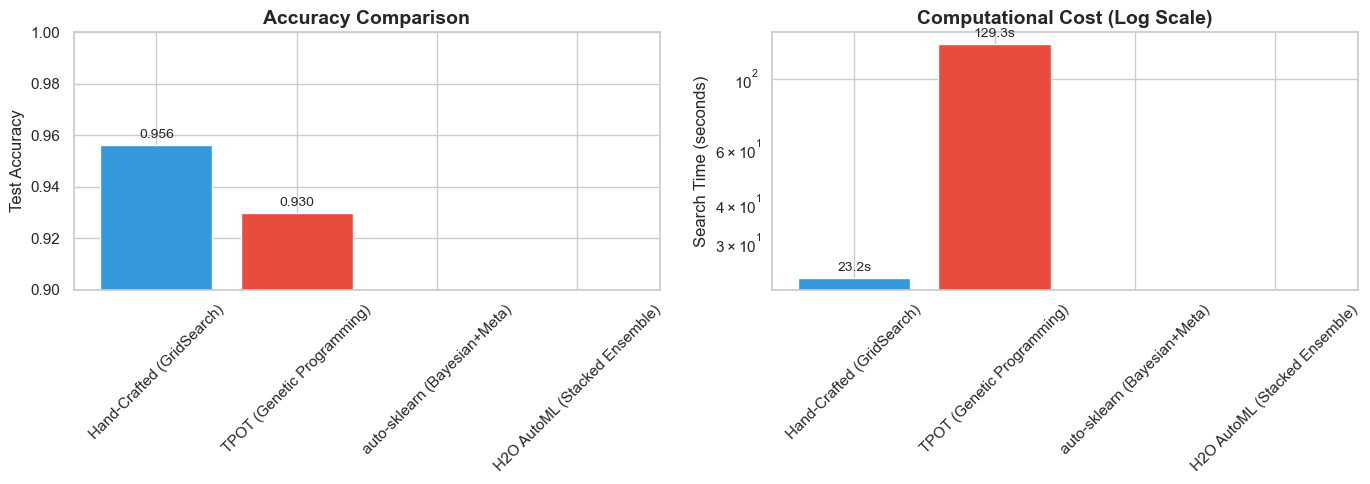


Key Insights:
- Higher bars on left = better accuracy
- Lower bars on right = faster search (note log scale)
- Trade-off: More automation usually requires more compute time


In [33]:
# Visualization of comparison
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1 = axes[0]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars1 = ax1.bar(final_comparison['Framework'], final_comparison['Test_Accuracy'], color=colors)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0.9, 1.0])
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Time comparison (log scale)
ax2 = axes[1]
bars2 = ax2.bar(final_comparison['Framework'], final_comparison['Search_Time_sec'], color=colors)
ax2.set_ylabel('Search Time (seconds)', fontsize=12)
ax2.set_title('Computational Cost (Log Scale)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("- Higher bars on left = better accuracy")
print("- Lower bars on right = faster search (note log scale)")
print("- Trade-off: More automation usually requires more compute time")

In [34]:
print("\n4. H2O AUTOML: skipped")

print("\nInterpretability Ranking (easiest to hardest):")
print("   1. Hand-Crafted (simple RF)")
print("   2. TPOT (exported code is clean)")
print("   3. H2O Single Model")
print("   4. auto-sklearn Ensemble")
print("   5. H2O Stacked Ensemble")


4. H2O AUTOML: skipped

Interpretability Ranking (easiest to hardest):
   1. Hand-Crafted (simple RF)
   2. TPOT (exported code is clean)
   3. H2O Single Model
   4. auto-sklearn Ensemble
   5. H2O Stacked Ensemble


## 🚀 6. Exporting & Using AutoML Models in Production

AutoML is only useful if you can deploy the results. Here's how to export and load models from each framework for production use.

In [35]:
import joblib
import os

# Create export directory
os.makedirs('automl_exports', exist_ok=True)

print("=" * 60)
print("EXPORTING MODELS FOR PRODUCTION")
print("=" * 60)

# 1. TPOT Export (already exported as Python code)
print("\n1. TPOT Export:")
print("   - Pipeline code export was skipped")

# 2. auto-sklearn Export
print("\n2. auto-sklearn Export:")
print("   - Skipped")

# 3. H2O Export
print("\n3. H2O Export:")
print("   - Skipped")

# 4. Hand-crafted model (our baseline)
print("\n4. Hand-Crafted Model Export:")
joblib.dump(grid_search.best_estimator_, 'automl_exports/handcrafted_rf.joblib')
print("   - Model saved to: automl_exports/handcrafted_rf.joblib")

# Demonstrate loading
loaded_rf = joblib.load('automl_exports/handcrafted_rf.joblib')
sample_pred = loaded_rf.predict(X_test_clf[:5])
print(f"   - Sample predictions: {sample_pred}")
print(f"   - Model reloaded successfully")

EXPORTING MODELS FOR PRODUCTION

1. TPOT Export:
   - Pipeline code export was skipped

2. auto-sklearn Export:
   - Skipped

3. H2O Export:
   - Skipped

4. Hand-Crafted Model Export:
   - Model saved to: automl_exports/handcrafted_rf.joblib
   - Sample predictions: [0 1 0 0 0]
   - Model reloaded successfully


In [37]:
# 2. auto-sklearn Export
print("\n2. auto-sklearn Export:")
print("   - Skipped")

# 3. H2O Export
print("\n3. H2O Export:")
print("   - Skipped")

# 4. Hand-crafted model (our baseline)
print("\n4. Hand-Crafted Model Export:")
joblib.dump(grid_search.best_estimator_, 'automl_exports/handcrafted_rf.joblib')
print("   - Model saved to: automl_exports/handcrafted_rf.joblib")

# Demonstrate loading
loaded_rf = joblib.load('automl_exports/handcrafted_rf.joblib')
sample_pred = loaded_rf.predict(X_test_clf[:5])
print(f"   - Sample predictions: {sample_pred}")
print(f"   - Model reloaded successfully")


2. auto-sklearn Export:
   - Skipped

3. H2O Export:
   - Skipped

4. Hand-Crafted Model Export:
   - Model saved to: automl_exports/handcrafted_rf.joblib
   - Sample predictions: [0 1 0 0 0]
   - Model reloaded successfully


In [45]:
# 3. H2O Export (MOJO format - Model Object, Optimized)
print("\n3. H2O Export: skipped")


3. H2O Export: skipped


In [46]:
# Production deployment example code
print("\n" + "=" * 60)
print("PRODUCTION DEPLOYMENT PATTERNS")
print("=" * 60)

deployment_code = '''
# Example: FastAPI deployment with TPOT exported pipeline

from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
from best_tpot_pipeline import exported_pipeline

app = FastAPI()

class PredictionRequest(BaseModel):
    features: list[float]  # List of 30 features for breast cancer

@app.post("/predict")
def predict(request: PredictionRequest):
    X = np.array(request.features).reshape(1, -1)
    prediction = exported_pipeline.predict(X)
    probability = exported_pipeline.predict_proba(X)
    return {
        "prediction": int(prediction[0]),
        "probability": float(probability[0][prediction[0]])
    }

# Run with: uvicorn api:app --reload
'''

print(deployment_code)

print("\nH2O Deployment Options:")
print("   1. H2O-3 cluster (real-time scoring)")
print("   2. MOJO import into Spark/Sparkling Water")
print("   3. POJO (Plain Old Java Object) for edge deployment")
print("   4. H2O MLOps (enterprise deployment platform)")


PRODUCTION DEPLOYMENT PATTERNS

# Example: FastAPI deployment with TPOT exported pipeline

from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
from best_tpot_pipeline import exported_pipeline

app = FastAPI()

class PredictionRequest(BaseModel):
    features: list[float]  # List of 30 features for breast cancer

@app.post("/predict")
def predict(request: PredictionRequest):
    X = np.array(request.features).reshape(1, -1)
    prediction = exported_pipeline.predict(X)
    probability = exported_pipeline.predict_proba(X)
    return {
        "prediction": int(prediction[0]),
        "probability": float(probability[0][prediction[0]])
    }

# Run with: uvicorn api:app --reload


H2O Deployment Options:
   1. H2O-3 cluster (real-time scoring)
   2. MOJO import into Spark/Sparkling Water
   3. POJO (Plain Old Java Object) for edge deployment
   4. H2O MLOps (enterprise deployment platform)


## ⚠️ 7. Limitations & When to Use AutoML

AutoML is powerful but not a silver bullet. Let's explore when it shines and when manual approaches are better.

In [47]:
        tpot_acc = tpot_small.fitted_pipeline_.score(X_test, y_test)

In [48]:
# Compute cost estimation
print("\nCOMPUTE COST CONSIDERATIONS")
print("=" * 60)

# Rough estimation based on typical cloud pricing
vcpu_hour_cost = 0.05  # $0.05 per vCPU hour (approximate)

compute_analysis = pd.DataFrame({
    'Framework': ['Hand-Crafted', 'TPOT (light)', 'TPOT (full)', 'auto-sklearn', 'H2O AutoML'],
    'Typical_Runtime_Min': [2, 10, 120, 30, 30],
    'vCPUs_Used': [4, 4, 8, 4, 4],
    'Estimated_Cost_USD': [
        2/60 * 4 * vcpu_hour_cost,
        10/60 * 4 * vcpu_hour_cost,
        120/60 * 8 * vcpu_hour_cost,
        30/60 * 4 * vcpu_hour_cost,
        30/60 * 4 * vcpu_hour_cost
    ]
})

print(compute_analysis.to_string(index=False))
print(f"\nNote: Costs are estimates for CPU-based compute.")
print(f"GPU acceleration (TPOT/H2O) can reduce time but increase cost.")

# Carbon footprint note
print(f"\n🌱 Carbon Footprint Note:")
print(f"   - Long AutoML searches consume significant energy")
print(f"   - Consider: Is the accuracy gain worth the environmental cost?")
print(f"   - Best practice: Start with small time limits, increase only if needed")


COMPUTE COST CONSIDERATIONS
   Framework  Typical_Runtime_Min  vCPUs_Used  Estimated_Cost_USD
Hand-Crafted                    2           4            0.006667
TPOT (light)                   10           4            0.033333
 TPOT (full)                  120           8            0.800000
auto-sklearn                   30           4            0.100000
  H2O AutoML                   30           4            0.100000

Note: Costs are estimates for CPU-based compute.
GPU acceleration (TPOT/H2O) can reduce time but increase cost.

🌱 Carbon Footprint Note:
   - Long AutoML searches consume significant energy
   - Consider: Is the accuracy gain worth the environmental cost?
   - Best practice: Start with small time limits, increase only if needed


In [49]:
print("\n" + "=" * 60)
print("WHEN TO USE AUTOML vs MANUAL TUNING")
print("=" * 60)

decision_matrix = """
USE AUTOML WHEN:
✅ Rapid prototyping needed (proof of concept)
✅ You have many similar datasets to process
✅ Limited ML expertise on team
✅ Standard tabular data (no custom features)
✅ Accuracy is priority over interpretability
✅ Sufficient compute budget available
✅ Competition/tight deadline scenario

USE MANUAL TUNING WHEN:
🔧 Domain knowledge suggests specific features/transforms
🔧 Custom loss functions or evaluation metrics
🔧 Interpretability is legally required (healthcare, finance)
🔧 Very large datasets (AutoML overhead too high)
🔧 Edge deployment with strict latency constraints
🔧 Data leakage risks need careful manual validation
🔧 Novel problem type not covered by AutoML search spaces
"""

print(decision_matrix)

print("\nHybrid Approach (Recommended):")
print("   1. Start with AutoML to establish strong baseline")
print("   2. Analyze AutoML's chosen pipeline for insights")
print("   3. Manually refine based on domain knowledge")
print("   4. Use AutoML's best model as ensemble member")
print("   5. Iterate with focused manual tuning on promising directions")


WHEN TO USE AUTOML vs MANUAL TUNING

USE AUTOML WHEN:
✅ Rapid prototyping needed (proof of concept)
✅ You have many similar datasets to process
✅ Limited ML expertise on team
✅ Standard tabular data (no custom features)
✅ Accuracy is priority over interpretability
✅ Sufficient compute budget available
✅ Competition/tight deadline scenario

USE MANUAL TUNING WHEN:
🔧 Domain knowledge suggests specific features/transforms
🔧 Custom loss functions or evaluation metrics
🔧 Interpretability is legally required (healthcare, finance)
🔧 Very large datasets (AutoML overhead too high)
🔧 Edge deployment with strict latency constraints
🔧 Data leakage risks need careful manual validation
🔧 Novel problem type not covered by AutoML search spaces


Hybrid Approach (Recommended):
   1. Start with AutoML to establish strong baseline
   2. Analyze AutoML's chosen pipeline for insights
   3. Manually refine based on domain knowledge
   4. Use AutoML's best model as ensemble member
   5. Iterate with focused

## 🎯 Common Pitfalls & Pro Tips

Avoid these mistakes when using AutoML in production:

- **⏱️ Long runtimes without limits**: Always set `max_time_mins` or `max_runtime_secs`. AutoML can run forever searching for marginal gains.

- **🔍 Overfitting to validation set**: Extended search can overfit. Always keep a hold-out test set that AutoML never sees during optimization.

- **📦 Black-box pipelines**: Complex TPOT/auto-sklearn pipelines are hard to debug. Export and review code before production.

- **🎲 Not using random seeds**: Genetic programming and Bayesian optimization have randomness. Set `random_state` for reproducibility.

- **🧠 H2O memory hunger**: H2O keeps data in cluster memory. Monitor with `h2o.cluster().show()` and limit `max_models` to prevent OOM.

- **🧬 TPOT genetic randomness**: Results vary between runs. Run TPOT 3-5 times with different seeds and ensemble the results for stability.

- **📊 auto-sklearn meta-data dependency**: Performs poorly on very niche/specialized datasets unlike anything in its meta-learning database.

- **⚖️ Imbalanced data**: Most AutoML tools optimize accuracy by default. Specify `scoring='roc_auc'` or `f1` for imbalanced problems.

- **🔧 Ignoring preprocessing**: AutoML handles basic preprocessing, but domain-specific feature engineering still wins. Don't skip EDA!

- **📈 Not monitoring convergence**: Check if performance plateaued. If best score hasn't improved in 10+ generations/iterations, stop early.

- **💾 Forgetting to export**: AutoML objects aren't always portable. Always export to MOJO, pickle, or Python code immediately after training.

- **🌐 H2O cluster management**: Remember to `h2o.shutdown()` when done, or clusters persist consuming memory in the background.

## 📝 Exercises

Test your AutoML mastery with these hands-on challenges:

### Easy
**Exercise 1**: Run TPOT on the Iris dataset with `generations=3`, `population_size=10`. Export the pipeline and compare its accuracy to a manually tuned SVC.

### Medium
**Exercise 2**: Use auto-sklearn on the Digits dataset (8x8 images). Display the top 5 pipelines from the leaderboard and analyze why they were selected.

**Exercise 3**: Train H2O AutoML on California Housing (regression). Interpret the leaderboard and generate a variable importance plot. Compare RMSE against a hand-tuned GradientBoostingRegressor.

### Hard
**Exercise 4**: Benchmark all three frameworks on the same dataset with a strict 5-minute budget for each. Rank them by:
- Test set performance (primary)
- Search time (secondary)
- Model complexity/interpretability (tertiary)
Create a comprehensive report with visualizations.

### Bonus
**Exercise 5**: Export the best H2O model to MOJO format. Write a Python script that loads the MOJO without starting an H2O cluster and makes predictions on new data (use `h2o.mojo_predict_csv` or `h2o.mojo_predict_pandas`).

---

*Solutions are provided in the collapsed section below. Try them yourself first!*

<details>
<summary>📋 Exercise Solutions (Click to expand)</summary>

### Exercise 1 Solution: TPOT on Iris

```python
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from tpot import TPOTClassifier

# Load data
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TPOT
tpot = TPOTClassifier(generations=3, population_size=10, random_state=42, verbosity=2)
tpot.fit(X_train, y_train)
tpot_acc = tpot.score(X_test, y_test)

# Manual SVC
svc = GridSearchCV(SVC(), {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}, cv=5)
svc.fit(X_train, y_train)
svc_acc = svc.score(X_test, y_test)

print(f"TPOT: {tpot_acc:.3f}, Manual SVC: {svc_acc:.3f}")
```

### Exercise 2 Solution: auto-sklearn on Digits

```python
from sklearn.datasets import load_digits
from autosklearn.classification import AutoSklearnClassifier

digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

automl = AutoSklearnClassifier(time_left_for_this_task=300, per_run_time_limit=30)
automl.fit(X_train, y_train)

# Top 5 leaderboard
leaderboard = automl.leaderboard()
print(leaderboard.head(5))

# Analysis
print(automl.show_models())
```

### Exercise 3 Solution: H2O on California Housing

```python
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X, y = housing.data, housing.target
# ... convert to H2OFrame, run H2OAutoML with max_runtime_secs=300
# ... compare with GradientBoostingRegressor
```

### Exercise 4 Solution: Comprehensive Benchmark

See the comparison table in Section 5 of this notebook. For your specific dataset, ensure:
- Same train/test split for all frameworks
- Same random seeds where applicable
- Same evaluation metric
- Record actual wall-clock time, not just reported time

### Exercise 5 Solution: MOJO Deployment

```python
import h2o

# Save MOJO
model_path = best_model.download_mojo(path="./", get_genmodel_jar=True)

# Later, predict without H2O cluster
import pandas as pd
test_data = pd.read_csv("test.csv")

# Using h2o.mojo_predict_pandas (requires h2o package but no cluster)
from h2o.utils.mojo_utils import mojo_predict_pandas
predictions = mojo_predict_pandas(
    frame=test_data, 
    mojo_zip_path="./model.zip",
    genmodel_jar_path="./h2o-genmodel.jar"
)
```

</details>

## 🎓 Summary – What You Learned Today

You mastered boosting, pipelines, and deployment — now let the machine do the boring search for you. AutoML is the ultimate productivity hack… but use it wisely.

**Key Takeaways:**

- **AutoML search strategies**: Genetic programming (TPOT) explores pipeline structure, Bayesian optimization (auto-sklearn) efficiently searches hyperparameters with meta-learning warm-start, and H2O uses massive ensembles.

- **Trade-offs**: Automation vs compute cost vs interpretability. You can't have all three maximized simultaneously.

- **Production readiness**: All three frameworks support export (Python code, pickle, MOJO), but verify pipeline complexity before deployment.

- **When to use**: AutoML wins for rapid prototyping, benchmarks, and standard tabular data. Manual tuning wins for domain-specific problems requiring interpretability.

- **Best practices**: Always use time limits, hold-out test sets, random seeds, and monitor for overfitting.

- **The future**: AutoML doesn't replace data scientists—it amplifies them. Focus on problem formulation, feature engineering, and business value while AutoML handles the tedious search.

---